# Trader Performance vs Market Sentiment
### How Bitcoin Fear & Greed sentiment relates to trader behaviour & performance on Hyperliquid

**TL;DR** — Sentiment is a **risk-monitoring** signal, not an alpha signal. The apparent
"traders earn more on Greed days" pattern **disappears once the Bitcoin price move is controlled**
(it is market beta, not a sentiment edge). The one clear behavioural shift is that traders take
**larger positions on Greed days** (large effect, but under-powered).

*This notebook orchestrates the pipeline in `src/` + `scripts/` and narrates the results. All
analytical logic lives in `src/`; this notebook does not re-implement it. Full methodology trail:
`ASSUMPTIONS_LOG.md`; detailed evidence in `outputs/`.*

## 1. Problem statement
**Objective:** uncover how market sentiment (Fear vs Greed) relates to trader behaviour and
performance, and whether any pattern is actionable.

**Two datasets:** (1) Bitcoin Fear & Greed Index (daily), (2) Hyperliquid historical trader data
(trade-level). **Approach:** clean → align by day → engineer behaviour/performance features →
aggregate to daily grain → merge sentiment → test pre-registered hypotheses with robust statistics,
controlling for the underlying market move.

## 2. Dataset overview

In [1]:
import sys, os
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
import pandas as pd
from src.config import load_config
cfg = load_config()
pd.DataFrame({
    "dataset": ["Fear & Greed Index", "Hyperliquid trades"],
    "rows": [2644, 211224], "columns": [4, 16],
    "coverage": ["2018-02-01 → 2025-05-02", "2023-05-01 → 2025-05-01"],
})

,dataset,rows,columns,coverage
0,Fear & Greed Index,2644,4,2018-02-01 → 2025-05-02
1,Hyperliquid trades,211224,16,2023-05-01 → 2025-05-01


**Verified data facts (see `outputs/data_quality_report.md`):** 0 missing / 0 duplicate rows in
both. Sentiment has a numeric value (0–100) **and** 5 classification buckets (not binary). The trade
file has **no leverage column** (so leverage is excluded, not fabricated), a lossy numeric timestamp
(the IST string is authoritative), and activity is **heavily concentrated** — 92% of trades fall in
the final 6 months, and the top 5 of 32 accounts are 50% of trades.

## 3. Pipeline overview
```
raw CSV ─▶ inspect ─▶ validate ─▶ clean ─▶ EDA
                                    │
             market-context (BTC proxy) ─┐
                                    ▼     ▼
        per-trade features ─▶ daily aggregation ─▶ MERGE (sentiment + proxy, UTC)
                                                        │
                       trader metrics ─▶ segmentation   ▼
                                             └─▶ STATISTICS ─▶ figures ─▶ insights
```
The cell below reproduces every artifact by running the module scripts in order (raw download is
skipped if the data is already present).

In [2]:
import subprocess
RUN_PIPELINE = True   # set False to skip and use existing outputs/
stages = [
    ("download raw",        "data/download.py"),
    ("M1 inspect",          "scripts/inspect_data.py"),
    ("M2 validate",         "scripts/validate_data.py"),
    ("M3 clean",            "scripts/clean_data.py"),
    ("M4 EDA figures",      "scripts/run_eda.py"),
    ("M5 market context",   "scripts/build_market_context.py"),
    ("M6 features",         "scripts/build_features.py"),
    ("M7 aggregate",        "scripts/build_aggregates.py"),
    ("M9 merge",            "scripts/build_merge.py"),
    ("M10 metrics",         "scripts/build_metrics.py"),
    ("M11 segments",        "scripts/build_segments.py"),
    ("M12 statistics",      "scripts/build_stats.py"),
    ("M13 stat figures",    "scripts/build_stat_figures.py"),
]
if RUN_PIPELINE:
    for name, script in stages:
        if script == "data/download.py" and Path("data/raw/hyperliquid_trades.csv").exists():
            print(f"• {name}: skipped (raw present)"); continue
        r = subprocess.run([sys.executable, script], capture_output=True, text=True)
        print(f"• {name}: {'OK' if r.returncode == 0 else 'FAILED'}")
        if r.returncode: print(r.stderr[-800:])


• download raw: skipped (raw present)


• M1 inspect: OK


• M2 validate: OK


• M3 clean: OK


• M4 EDA figures: OK


...

• M9 merge: OK


• M10 metrics: OK


• M11 segments: OK


• M12 statistics: OK


• M13 stat figures: OK


## 4. Key EDA findings
Frozen in `outputs/eda_summary.md` (E1–E6):
- **E1** Realized PnL is extremely heavy-tailed (skew 22, win rate 83%) → non-parametric tests.
- **E2** 92% of trades are in the final 6 months → volume concentration caveat.
- **E3** Whale concentration (Gini 0.57, top-5 = 50%) → per-account paired designs.
- **E4** Sentiment is Greed-tilted (Greed 309 / Fear 103 / Neutral 64 market-days).
- **E5** Directional baseline: 47% Long / 36% Short / 17% Spot.
- **E6** Trade size spans 8 orders of magnitude → medians, not means.

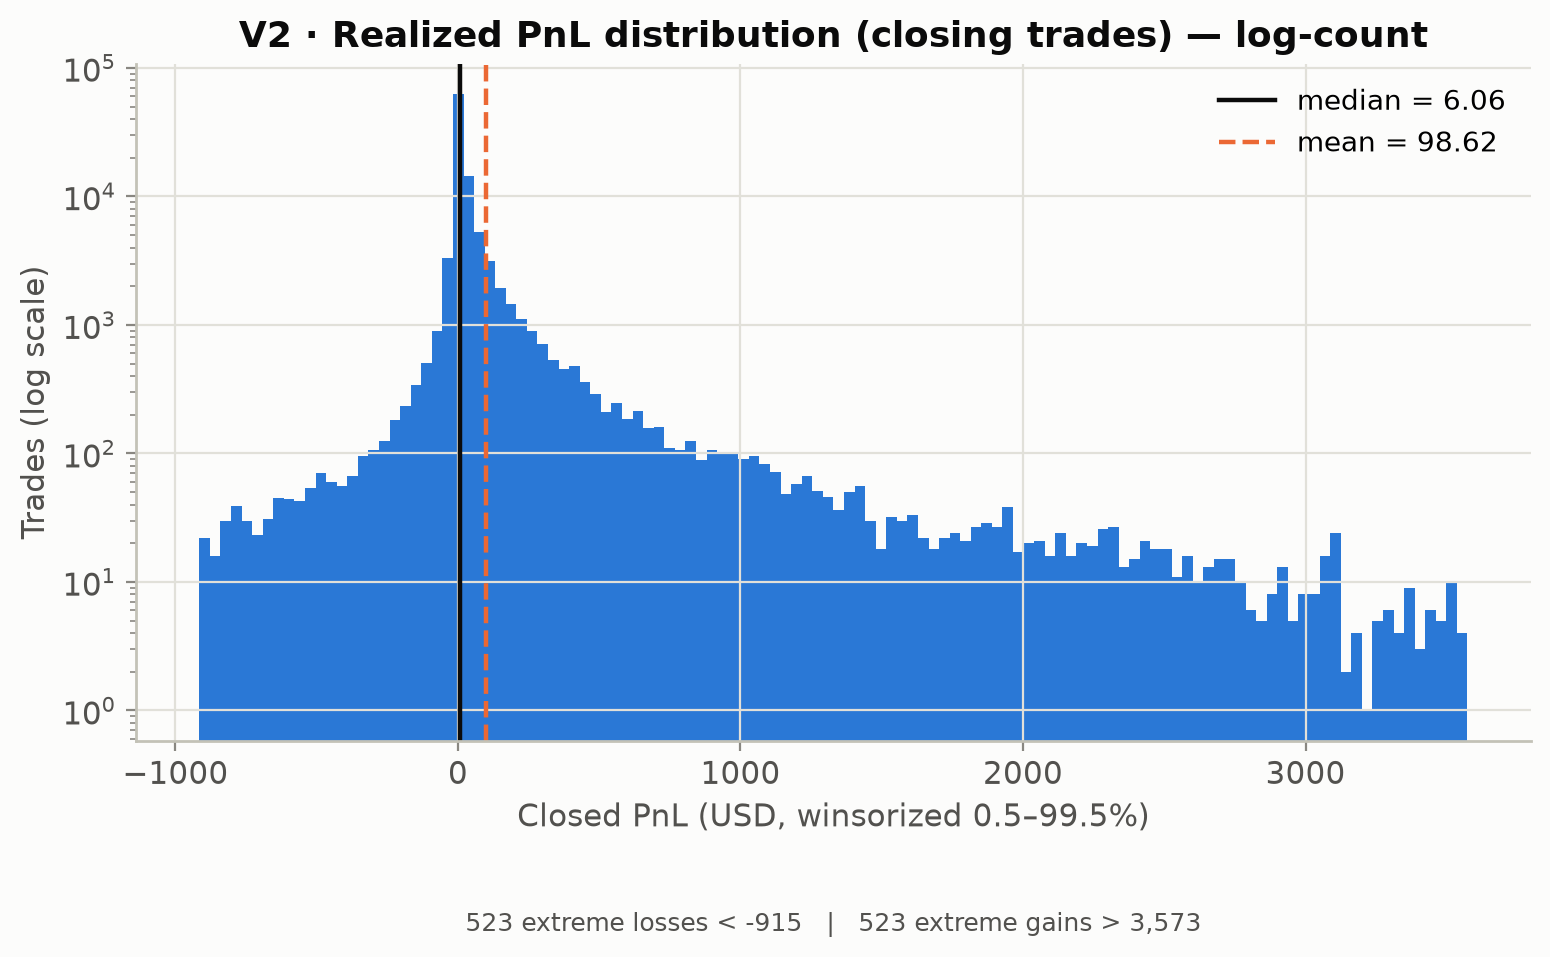

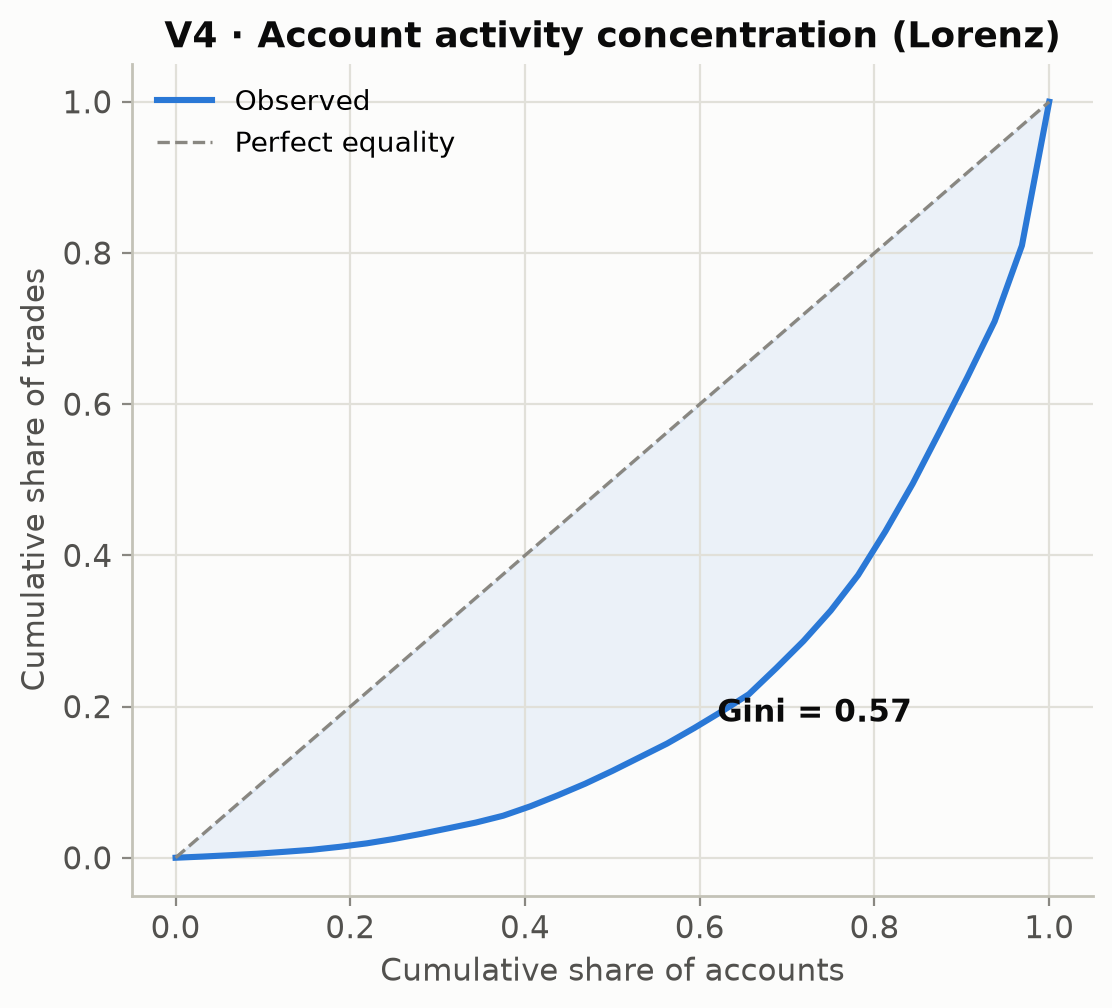

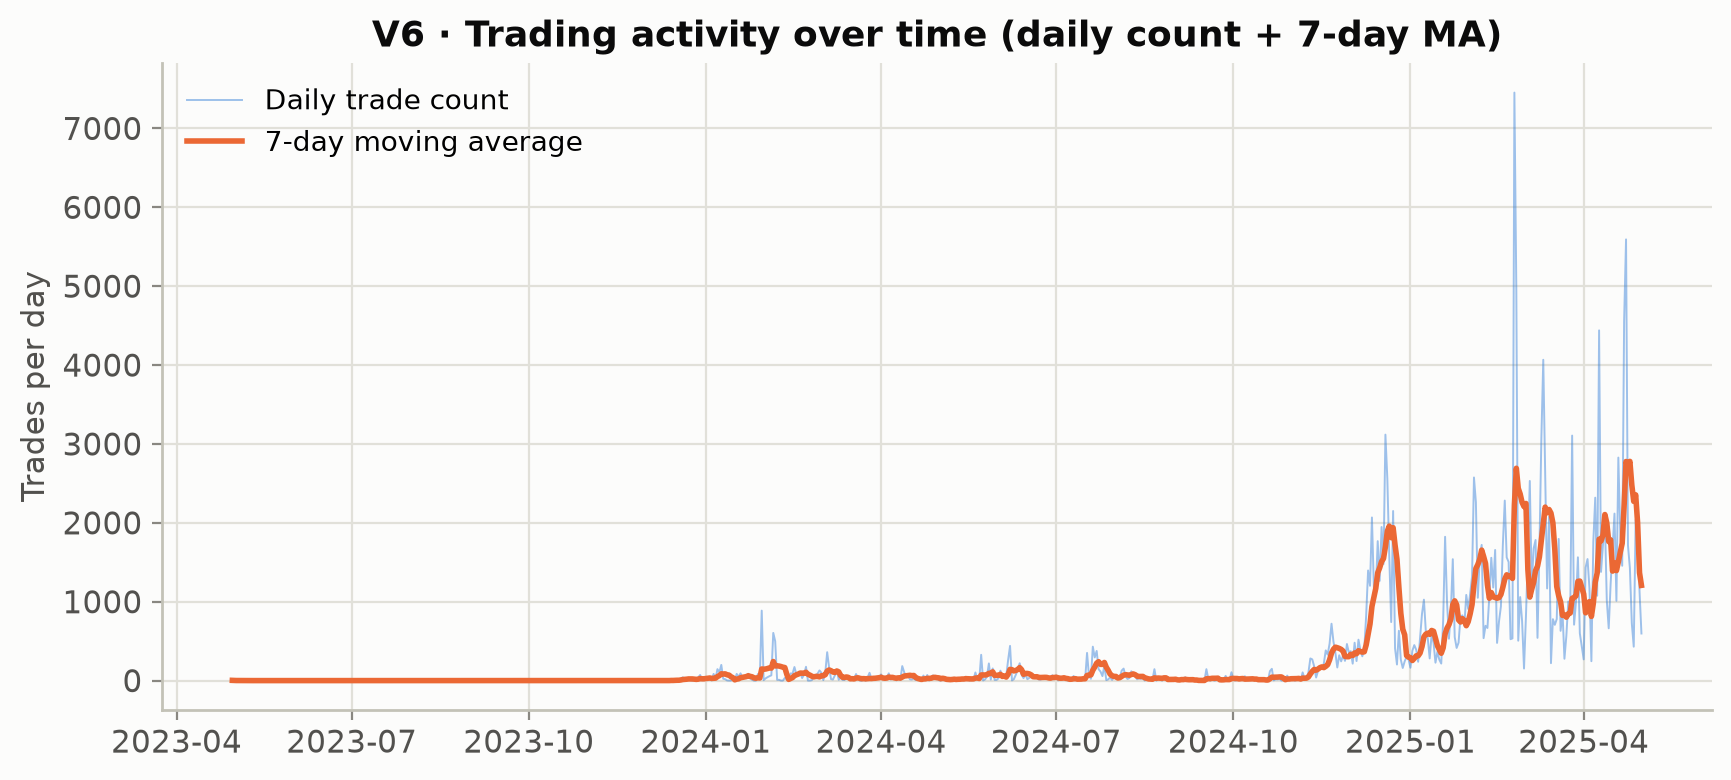

In [3]:
from IPython.display import Image, display
for f in ["v2_realized_pnl_distribution", "v4_account_activity_concentration_lorenz",
          "v6_trading_activity_over_time"]:
    display(Image(filename=f"outputs/figures/{f}.png", width=760))

## 5. Feature engineering summary
**Per-trade (`src/features.py`):** win flag, position side, return-on-notional, fee bps, and a
**self-normalized `size_z`** (trade size vs the account's *own* history). **Trader-level
(`src/metrics.py`, 13 metrics):** profitability (profit factor, expectancy, ROI-on-notional), risk
(max drawdown, CVaR), consistency (win rate, % profitable days), behaviour (frequency, size,
long-ratio). **Confounder control (`src/market_context.py`):** an *in-sample BTC market proxy*
(median BTC-perp price → return & volatility; ~60% day coverage) to separate sentiment from the
market move. **Segments (`src/segments.py`):** 4 quantile + 1 rule-based; clustering evaluated and
rejected (silhouette 0.26, no clean structure at n=32).

In [4]:
from src.io_utils import load_parquet
seg = load_parquet("data/processed/trader_segments.parquet")
seg[["directional_segment"]].value_counts().to_frame("traders")

,traders
directional_segment,
Long-biased,16
Short-biased,14
Balanced,2


## 6. Statistical methodology
Seven **pre-registered** research questions, one test each — not fished (`outputs/statistical_analysis.md`).
Design: **per-trader paired** tests (each trader its own control, respecting whale-driven
non-independence), **non-parametric** by default (heavy tails), **bootstrap CIs**, **effect sizes**
weighted equally with p-values, **FDR** correction, and a **confounder-controlled** regression
(sentiment effect after BTC return + volatility). Neutral days excluded only inside binary tests.

## 7. Results

In [5]:
res = load_parquet("data/processed/stat_results.parquet")
res["significant_FDR"] = res["p_adjusted"] < 0.05
res[["rq", "question", "test", "p_value", "p_adjusted", "significant_FDR",
     "effect_name", "effect_value", "effect_magnitude"]]

,rq,question,test,p_value,p_adjusted,significant_FDR,effect_name,effect_value,effect_magnitude
0,RQ1,Does the typical account's daily PnL differ on...,Mann–Whitney U (independent),0.042291,0.098679,False,Cliff's delta,0.133,negligible
1,RQ2,Do individual traders realize different daily ...,Wilcoxon signed-rank (paired),0.360567,0.504793,False,matched-pairs rank-biserial,-0.213,small
2,RQ3,Do traders' win rates differ on Fear vs Greed ...,Wilcoxon signed-rank (paired),0.191898,0.335821,False,matched-pairs rank-biserial,0.298,small
3,RQ5,Do traders trade more/less frequently on Fear ...,Wilcoxon signed-rank (paired),0.481196,0.561396,False,matched-pairs rank-biserial,-0.154,small
4,RQ4,Do traders use different position sizes on Fea...,Wilcoxon signed-rank (paired),0.023951,0.083827,False,matched-pairs rank-biserial,0.571,large
5,RQ6,Is sentiment associated with trade direction (...,Chi-square test of independence,0.000000,0.000000,True,Cramér's V,0.191,small
6,RQ7,Does sentiment predict daily PnL AFTER control...,OLS with robust (HC3) SE; market-day grain,0.757325,0.757325,False,"Greed coefficient (USD/day, market-median)",65.410,negligible


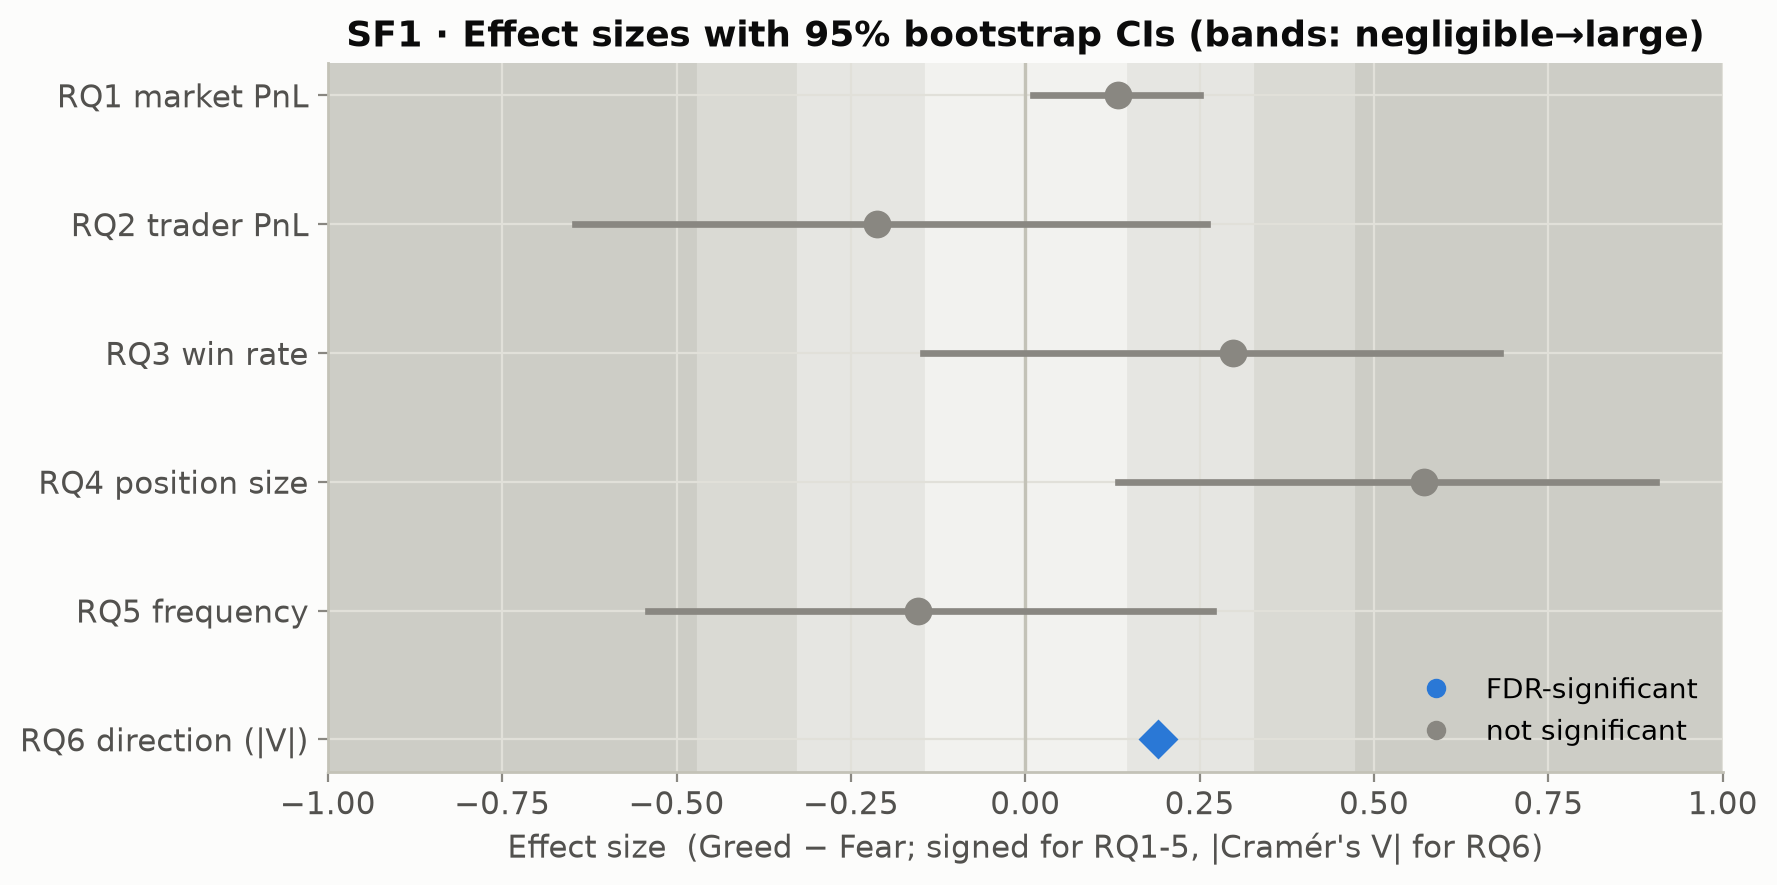

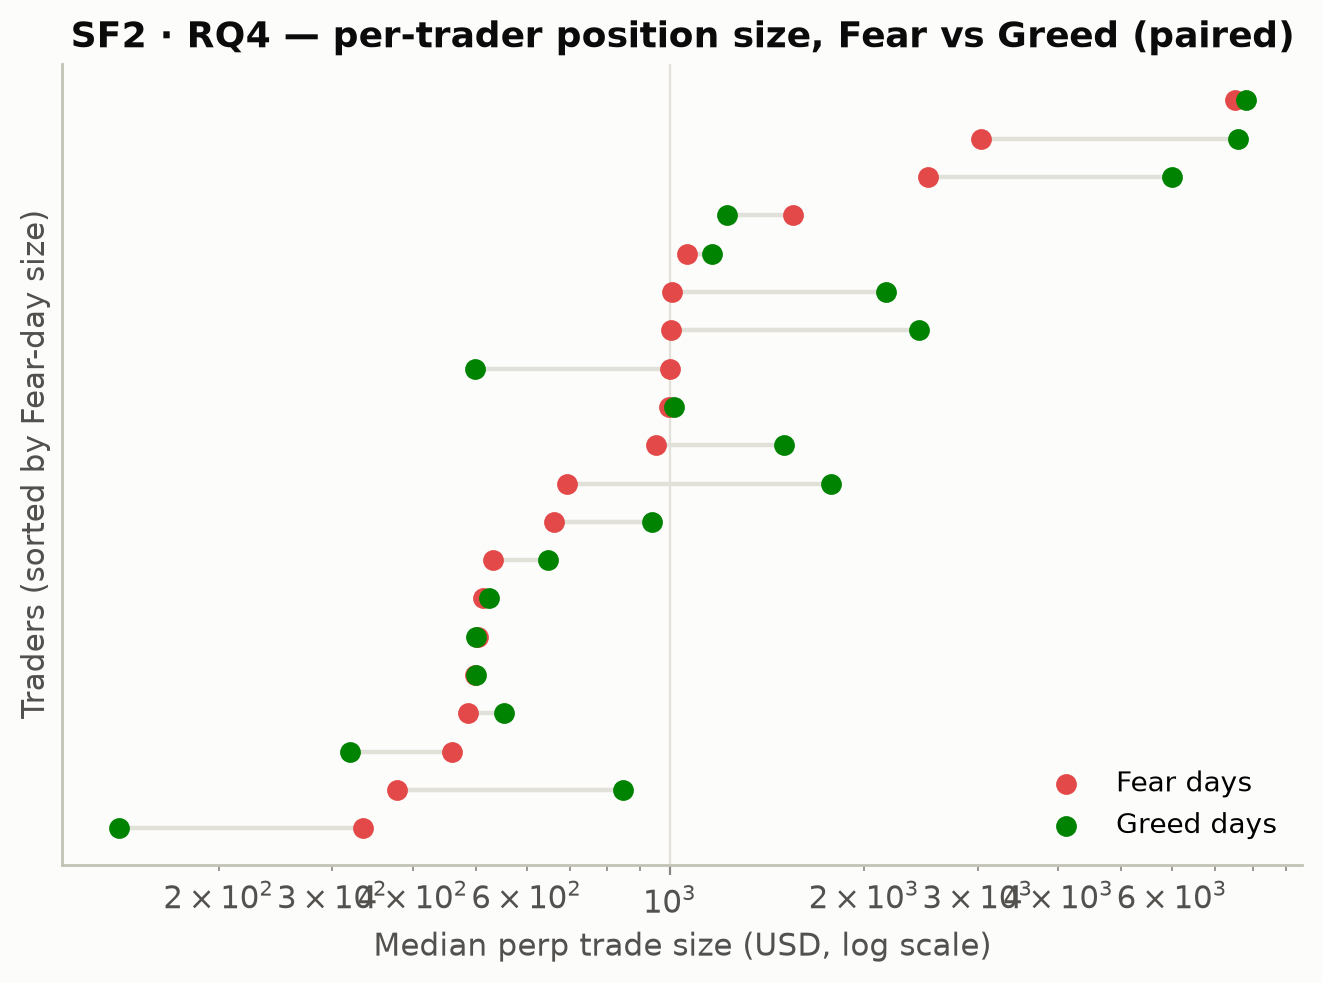

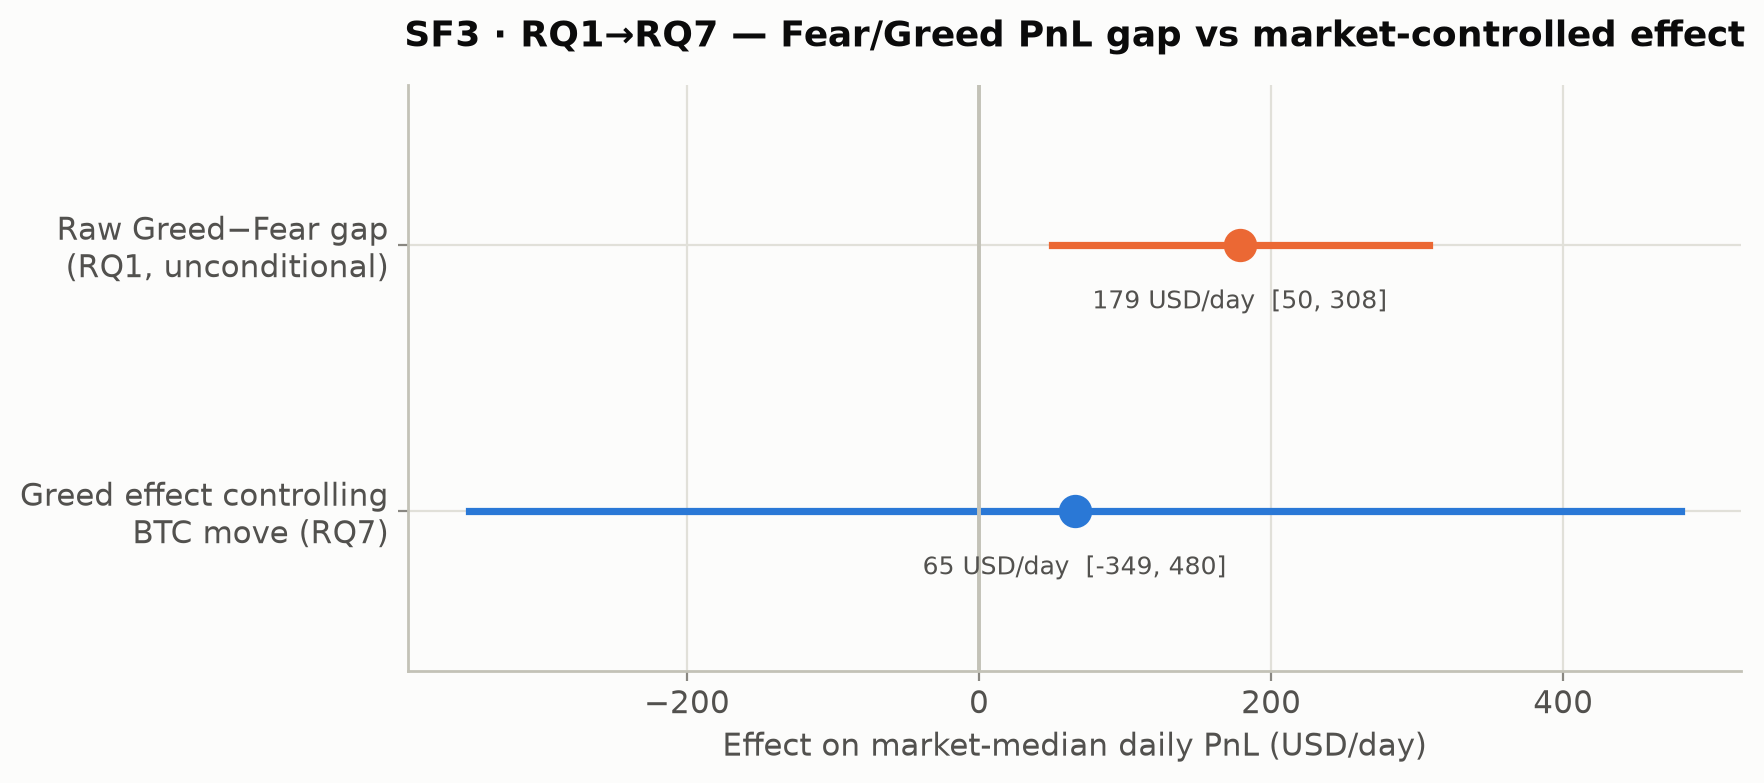

In [6]:
for f in ["sf1_effect_size_forest", "sf2_rq4_position_size_dumbbell",
          "sf3_rq7_confounder_coefficient"]:
    display(Image(filename=f"outputs/figures/{f}.png", width=780))

**Reading the results:**
- **RQ1→RQ7 (confounder):** the raw Greed−Fear PnL gap (+179 USD/day) collapses to +65 with a CI
  crossing zero once the market move is controlled → **the edge is market beta, not sentiment**.
- **RQ4 (position size):** *large* effect — traders size up on Greed days (+107 USD median) — but
  **under-powered** (20 traders, FDR p=0.084): likely, not confirmed.
- **RQ6 (direction):** significant but **small** (Cramér's V 0.19) — sentiment barely shifts long/short.
- **RQ2/RQ3/RQ5:** no reliable difference in per-trader PnL, win rate, or frequency.

## 8. Business insights & recommendations
Full report: `outputs/business_insights.md`.
- **Confirmed:** the Greed PnL "edge" is a market-direction artifact; sentiment↔direction association is real but small.
- **Likely:** traders take larger positions in Greed (risk-on sizing) — under-powered.
- **Exploratory / none:** marginally higher Greed win rate (weak); no PnL or frequency difference.

**R1 — Regime-aware position-size discipline in Greed** (risk control; confidence *Low–Medium*, prudential not proven-profit).
**R2 — Do not use Fear/Greed as a standalone performance/timing signal** (confidence *Medium–High*; a well-supported null after market control).

## 9. Limitations
- **No leverage/equity data** — "size" is notional, not leverage (D3).
- **32 accounts**, whale- and time-concentrated (E2/E3) → not generalisable to all traders.
- **In-sample BTC proxy** (~60% coverage) rather than an external benchmark (D11).
- **Associational only** — no causal claims; Fear-day estimates are the least powered (103 days).
- Daily grain; intraday/holding-period behaviour not reconstructable.

## 10. Future work
Account **equity/margin** data (true leverage) · an **external BTC benchmark** · **more accounts &
denser history** (power for RQ2–RQ5) · **entry–exit linkage** (holding periods, drawdown-by-regime) ·
a **pre-registered out-of-sample test** of R1 before any deployment.

---
*Reproduce: `pip install -r requirements.txt` then Run-All (raw data auto-downloads). Methodology &
decisions: `ASSUMPTIONS_LOG.md`. Reports & figures: `outputs/`.*